<a href="https://colab.research.google.com/github/1322vishav/Image-Processing/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


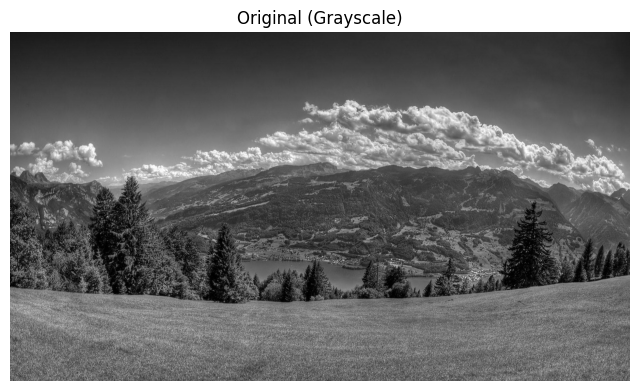

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image_path='/content/drive/MyDrive/image.jpg'
image=cv2.imread(image_path)
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.figure(figsize=(8,8))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title('Original (Grayscale)')
plt.show()

## Q1: Log Transform (c = 1)

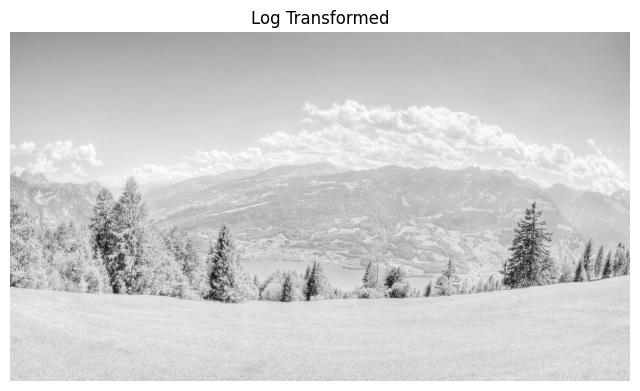

In [3]:
c = 1
log_img = c * np.log(1 + gray)

log_img = (log_img / log_img.max()) * 255
log_img = log_img.astype(np.uint8)

plt.figure(figsize=(8,8))
plt.imshow(log_img, cmap='gray')
plt.axis('off')
plt.title('Log Transformed')
plt.show()

## Q2: Power Law / Gamma Transform (c = 1)

Enter gamma value: .4


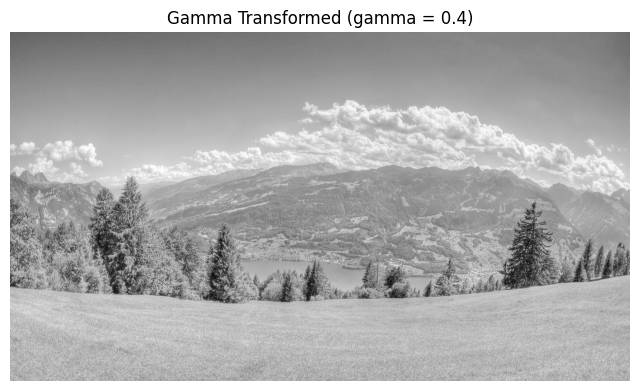

In [4]:
c = 1
gamma = float(input("Enter gamma value: "))

gray_norm = gray / 255.0
gamma_img = c * np.power(gray_norm, gamma)

gamma_img = gamma_img * 255
gamma_img = gamma_img.astype(np.uint8)

plt.figure(figsize=(8,8))
plt.imshow(gamma_img, cmap='gray')
plt.axis('off')
plt.title(f'Gamma Transformed (gamma = {gamma})')
plt.show()

## Q3: Intensity Level Slicing (Contrast Stretching)

Enter input range lower bound (r1): 80
Enter input range upper bound (r2): 120
Enter output range lower bound (s1): 50
Enter output range upper bound (s2): 150


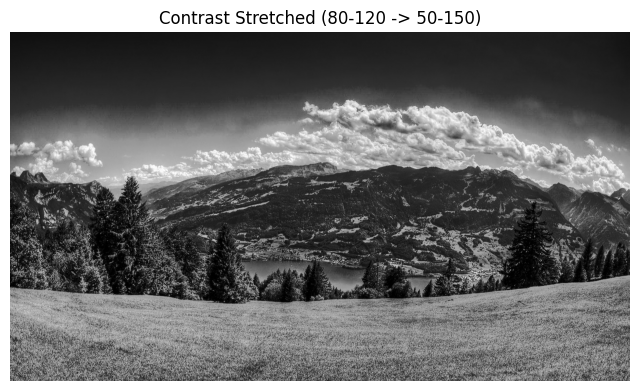

In [5]:
r1 = int(input("Enter input range lower bound (r1): "))
r2 = int(input("Enter input range upper bound (r2): "))
s1 = int(input("Enter output range lower bound (s1): "))
s2 = int(input("Enter output range upper bound (s2): "))

stretched = np.zeros_like(gray)

# Below r1: scale 0..r1 to 0..s1
mask_low = gray < r1
stretched[mask_low] = (s1 / r1) * gray[mask_low]

# Between r1 and r2: scale to s1..s2
mask_mid = (gray >= r1) & (gray <= r2)
stretched[mask_mid] = ((s2 - s1) / (r2 - r1)) * (gray[mask_mid] - r1) + s1

# Above r2: scale r2..255 to s2..255
mask_high = gray > r2
stretched[mask_high] = ((255 - s2) / (255 - r2)) * (gray[mask_high] - r2) + s2

stretched = np.clip(stretched, 0, 255).astype(np.uint8)

plt.figure(figsize=(8,8))
plt.imshow(stretched, cmap='gray')
plt.axis('off')
plt.title(f'Contrast Stretched ({r1}-{r2} -> {s1}-{s2})')
plt.show()